# E-Commerce Customer Analytics — Exploratory Visualizations

This notebook produces the visualizations used in the project README and Tableau dashboard. The underlying analysis lives in the SQL files; this notebook focuses on translating those findings into clear visual narratives.

**Author:** Mubina Mirzaeva
**Dataset:** Olist Brazilian E-Commerce, 2016–2018
**Source queries:** `sql/00_setup.sql` through `sql/04_satisfaction_operations.sql`

In [2]:
%pip install seaborn psycopg2-binary pandas matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

# Visual styling for all charts in this notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

# Connect to the Olist database
conn = psycopg2.connect(
    dbname="olist",
    user="mubinamirzaeva",
    host="localhost",
    port=5432
)

print("Connected to Olist database.")

Connected to Olist database.


## Revenue Trend, 2017–2018

Olist's growth trajectory during the dataset window. Revenue is calculated from delivered orders only, with the truncated October 2018 partial month excluded for trend clarity.

/var/folders/_r/wy82kxwx1fx4tthd4qhw7knc0000gn/T/ipykernel_45683/1232594441.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  revenue_df = pd.read_sql(revenue_query, conn)


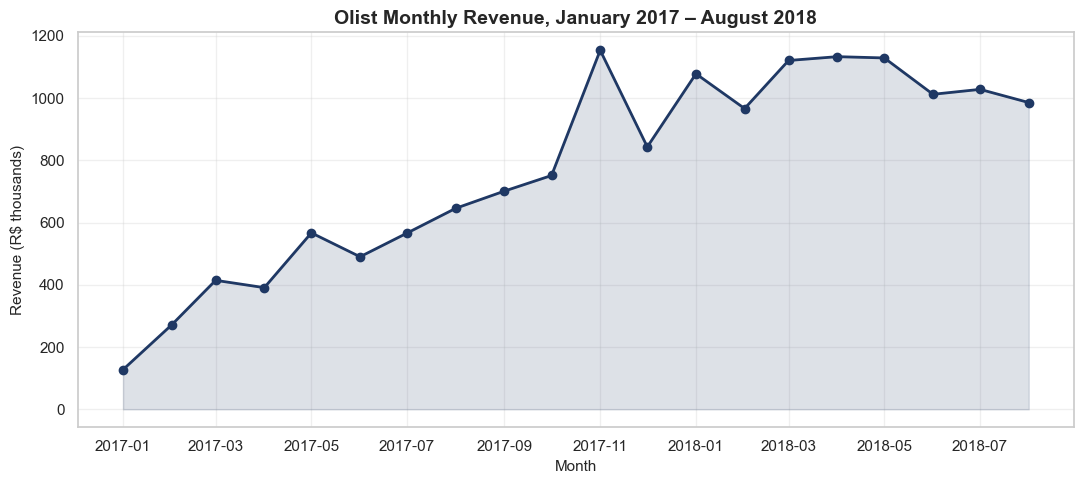

Total revenue over the period: R$15,373,120
Total orders over the period: 96,211


In [4]:
revenue_query = """
WITH order_revenue AS (
    SELECT
        oi.order_id,
        SUM(oi.price + oi.freight_value) AS order_total
    FROM order_items oi
    GROUP BY oi.order_id
)
SELECT
    DATE_TRUNC('month', o.order_purchase_timestamp)::DATE AS month,
    COUNT(DISTINCT o.order_id) AS orders,
    ROUND(SUM(orev.order_total)::NUMERIC, 2) AS revenue
FROM orders o
JOIN order_revenue orev ON o.order_id = orev.order_id
WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp >= '2017-01-01'
  AND o.order_purchase_timestamp < '2018-09-01'
GROUP BY month
ORDER BY month;
"""

revenue_df = pd.read_sql(revenue_query, conn)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(revenue_df["month"], revenue_df["revenue"] / 1000, marker="o", linewidth=2, color="#1f3864")
ax.fill_between(revenue_df["month"], revenue_df["revenue"] / 1000, alpha=0.15, color="#1f3864")
ax.set_title("Olist Monthly Revenue, January 2017 – August 2018")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (R$ thousands)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../dashboard/01_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total revenue over the period: R${revenue_df['revenue'].sum():,.0f}")
print(f"Total orders over the period: {revenue_df['orders'].sum():,}")